<a href="https://colab.research.google.com/github/NandaKishore-04/Website-Traffic-Analysis/blob/main/Website_Traffic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# PROJECT 3: WEBSITE TRAFFIC ANALYSIS
# Phase 1 - Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Plot style
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("/content/traffic.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
# Display first five rows

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [ ]:
df.tail()

,event,date,country,city,artist,album,track,isrc,linkid
226273,pageview,2021-08-24,Kuwait,Kuwait City,Sean Paul,The Trinity,Temperature,USAT20505520,04ba6b17-1055-4f0e-a75e-3cdb0d0d4106
226274,pageview,2021-08-24,India,Chennai,Miscél,when you left,when you left,QM42K1907890,2fc15e8b-83aa-40ee-9f9d-5d96c6d4356c
226275,pageview,2021-08-24,India,Jaipur,"Trippie Redd, Lil Uzi Vert",Holy Smokes (feat. Lil Uzi Vert),Holy Smokes,QZJ842001118,eedc8702-6bd2-499a-972f-260c35f72e0f
226276,pageview,2021-08-24,France,Unknown,Young Thug,Tick Tock,Tick Tock,USAT22104514,e0a76dc3-7ccd-405f-8ee8-a2c55c0e0ed2
226277,pageview,2021-08-24,Iraq,Duhok,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (226278, 9)


In [ ]:
print(df.columns)

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [ ]:
df.describe(include="all")

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


In [ ]:
df.sample(10)

,event,date,country,city,artist,album,track,isrc,linkid
16816,click,2021-08-19,United Arab Emirates,Dubai,"Pop Smoke, Lil Tjay",Shoot For The Stars Aim For The Moon,Mood Swings (feat. Lil Tjay),USUM72013632,9d325586-9453-4664-88e8-cdf24c43ffa0
128992,pageview,2021-08-20,United States,Harlingen,Anne-Marie,Beautiful,Beautiful,GBAHS2100225,522da5cc-8177-4140-97a7-a84fdb4caf1c
198644,pageview,2021-08-20,Saudi Arabia,Jeddah,Why Don't We,The Good Times and The Bad Ones,Love Song,USAT22007277,4bd6fbda-d0be-435b-82e3-782d0a57235f
44048,click,2021-08-25,United Kingdom,Manchester,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
106165,pageview,2021-08-22,United States,Lakeland,"Kayla Nicole, Taylor Girlz, Flo Milli","Bundles 2 (feat. Flo Milli, Taylor Girlz)","Bundles 2 (feat. Flo Milli, Taylor Girlz)",QMCE32100359,fbf4b935-f961-4b13-b1d8-45ad47093559
161496,pageview,2021-08-24,Mauritania,Unknown,"Lola Indigo, TINI, Belinda",La Niña,La Niña de la Escuela,ES5702100732,7c8bbf79-21c7-4b33-acaf-c8bf5a45c333
70356,preview,2021-08-24,Saudi Arabia,Riyadh,"Surfaces, Tai Verdes",Sheesh!,Sheesh!,QZJ842001135,5dacbf0e-f422-4a48-b432-d8d7ad5c60c4
43954,click,2021-08-24,India,Ahmedabad,"Surf Mesa, Emilee",ily (i love you baby) (feat. Emilee),ily (i love you baby) (feat. Emilee),QZJRC1945204,c2c876ab-b093-4750-9449-6b4913da6af3
106492,pageview,2021-08-25,United States,Los Angeles,PinkPantheress,Just for me,Just for me,GBAYE2101058,e2e39afa-648b-4163-97b0-ce742ea67550
56298,preview,2021-08-24,Saudi Arabia,Riyadh,"Jack Harlow, Pooh Shiesty",SUVs (Black on Black),SUVs (Black on Black),USAT22102616,30ee2950-0e66-47da-87cc-056ab2de284d


In [ ]:
df.dtypes

,0
event,object
date,object
country,object
city,object
artist,object
album,object
track,object
isrc,object
linkid,object


In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

event: 3
date: 7
country: 211
city: 11993
artist: 2419
album: 3254
track: 3562
isrc: 709
linkid: 3839


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

country      11
city         11
artist       37
album         5
track         5
isrc       7121
dtype: int64


In [ ]:
# ==========================================
# Fill Missing Values
# ==========================================

# Fill categorical columns with "Unknown"

categorical_cols = ['country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64


In [ ]:
# ==========================================
# Duplicate Records
# ==========================================

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 103711


In [ ]:
# ==========================================
# Remove Duplicate Records
# ==========================================

df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

print("Duplicate Records:", df.duplicated().sum())

Dataset Shape: (122567, 9)
Duplicate Records: 0


In [ ]:
# ==========================================
# Convert Date
# ==========================================

df["date"] = pd.to_datetime(df["date"])

print(df["date"].dtype)

datetime64[ns]


In [ ]:
print("Start Date :", df["date"].min())

print("End Date :", df["date"].max())

Start Date : 2021-08-19 00:00:00
End Date : 2021-08-25 00:00:00


In [ ]:
df.dtypes

,0
event,object
date,datetime64[ns]
country,object
city,object
artist,object
album,object
track,object
isrc,object
linkid,object


In [ ]:
# ==========================================
# Clean Text Columns
# ==========================================

text_columns = [
    "country",
    "city",
    "artist",
    "album",
    "track"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print("Text Cleaning Completed!")

Text Cleaning Completed!


In [ ]:
print(df.isnull().sum())

event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122567 entries, 0 to 226274
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    122567 non-null  object        
 1   date     122567 non-null  datetime64[ns]
 2   country  122567 non-null  object        
 3   city     122567 non-null  object        
 4   artist   122567 non-null  object        
 5   album    122567 non-null  object        
 6   track    122567 non-null  object        
 7   isrc     122567 non-null  object        
 8   linkid   122567 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 9.4+ MB


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (122567, 9)


In [ ]:
# ==========================================
# Save Cleaned Dataset
# ==========================================

df.to_csv(
    "cleaned website traffic dataset.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!


In [ ]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [ ]:
# ==========================================
# Feature Engineering
# Create Year
# ==========================================

df["Year"] = df["date"].dt.year

df[["date", "Year"]].head()

,date,Year
0,2021-08-21,2021
2,2021-08-21,2021
3,2021-08-21,2021
4,2021-08-21,2021
5,2021-08-21,2021


In [ ]:
# Create Month Number

df["Month"] = df["date"].dt.month

df[["date", "Month"]].head()

,date,Month
0,2021-08-21,8
2,2021-08-21,8
3,2021-08-21,8
4,2021-08-21,8
5,2021-08-21,8


In [ ]:
# Create Month Name

df["Month_Name"] = df["date"].dt.month_name()

df[["date", "Month_Name"]].head()

,date,Month_Name
0,2021-08-21,August
2,2021-08-21,August
3,2021-08-21,August
4,2021-08-21,August
5,2021-08-21,August


In [ ]:
# Create Day

df["Day"] = df["date"].dt.day

df[["date", "Day"]].head()

,date,Day
0,2021-08-21,21
2,2021-08-21,21
3,2021-08-21,21
4,2021-08-21,21
5,2021-08-21,21


In [ ]:
# Create Day Name

df["Day_Name"] = df["date"].dt.day_name()

df[["date", "Day_Name"]].head()

,date,Day_Name
0,2021-08-21,Saturday
2,2021-08-21,Saturday
3,2021-08-21,Saturday
4,2021-08-21,Saturday
5,2021-08-21,Saturday


In [ ]:
# Weekend or Weekday

df["Week_Type"] = np.where(
    df["Day_Name"].isin(["Saturday", "Sunday"]),
    "Weekend",
    "Weekday"
)

df["Week_Type"].value_counts()

,count
Week_Type,
Weekday,88939
Weekend,33628


In [ ]:
# Event Category

df["Event_Category"] = df["event"].str.title()

df["Event_Category"].value_counts()

,count
Event_Category,
Pageview,73360
Click,32499
Preview,16708


In [ ]:
# Top Country Flag

top_countries = df["country"].value_counts().head(10).index

df["Top_Country"] = np.where(
    df["country"].isin(top_countries),
    "Top Country",
    "Other"
)

df["Top_Country"].value_counts()

,count
Top_Country,
Top Country,84972
Other,37595


In [ ]:
# Top Artist Flag

top_artists = df["artist"].value_counts().head(10).index

df["Top_Artist"] = np.where(
    df["artist"].isin(top_artists),
    "Top Artist",
    "Other"
)

df["Top_Artist"].value_counts()

,count
Top_Artist,
Other,86823
Top Artist,35744


In [ ]:
# Top Album Flag

top_albums = df["album"].value_counts().head(10).index

df["Top_Album"] = np.where(
    df["album"].isin(top_albums),
    "Top Album",
    "Other"
)

df["Top_Album"].value_counts()

,count
Top_Album,
Other,86735
Top Album,35832


In [ ]:
# Traffic Category based on Event

traffic_mapping = {
    "pageview": "Viewed",
    "click": "Clicked",
    "preview": "Previewed"
}

df["Traffic_Category"] = (
    df["event"]
    .str.lower()
    .map(traffic_mapping)
    .fillna("Other")
)

df["Traffic_Category"].value_counts()

,count
Traffic_Category,
Viewed,73360
Clicked,32499
Previewed,16708


In [ ]:
print(df.columns)

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid', 'Year', 'Month', 'Month_Name', 'Day', 'Day_Name', 'Week_Type',
       'Event_Category', 'Top_Country', 'Top_Artist', 'Top_Album',
       'Traffic_Category'],
      dtype='object')


In [ ]:
# Save Feature Engineered Dataset

df.to_csv(
    "website traffic feature engineered.csv",
    index=False
)

print("Feature Engineered Dataset Saved Successfully!")

Feature Engineered Dataset Saved Successfully!


In [ ]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid,Year,Month,Month_Name,Day,Day_Name,Week_Type,Event_Category,Top_Country,Top_Artist,Top_Album,Traffic_Category
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,2021,8,August,21,Saturday,Weekend,Click,Top Country,Top Artist,Top Album,Clicked
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2,2021,8,August,21,Saturday,Weekend,Click,Top Country,Top Artist,Top Album,Clicked
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd,2021,8,August,21,Saturday,Weekend,Click,Top Country,Other,Other,Clicked
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,2021,8,August,21,Saturday,Weekend,Click,Other,Top Artist,Top Album,Clicked
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02,2021,8,August,21,Saturday,Weekend,Click,Top Country,Other,Other,Clicked


/tmp/ipykernel_13463/590323736.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


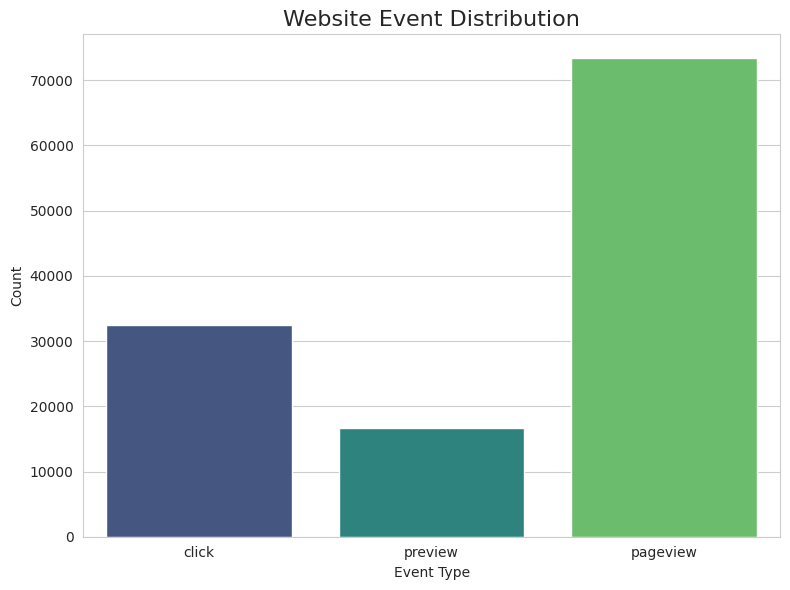

In [ ]:
# Chart 1: Event Distribution

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="event",
    palette="viridis"
)

plt.title("Website Event Distribution", fontsize=16)
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("Website Event Distribution.png", dpi=300)

plt.show()

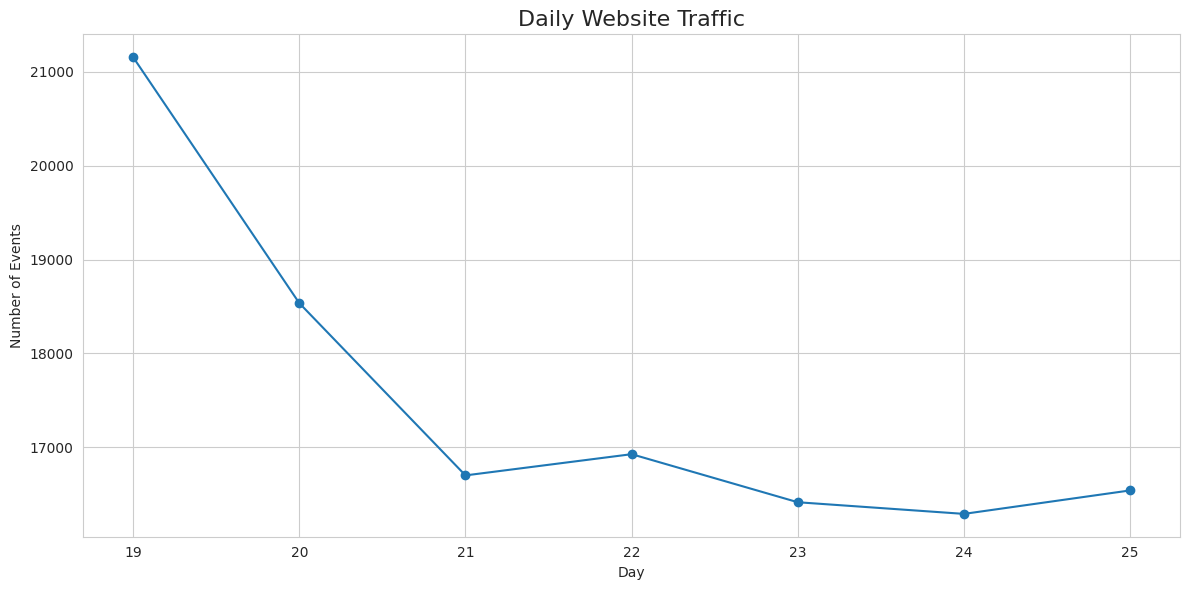

In [ ]:
# Chart 2: Daily Website Traffic

daily = df.groupby("Day").size()

plt.figure(figsize=(12,6))

plt.plot(
    daily.index,
    daily.values,
    marker="o"
)

plt.title("Daily Website Traffic", fontsize=16)
plt.xlabel("Day")
plt.ylabel("Number of Events")

plt.tight_layout()

plt.savefig("Daily Website Traffic.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/2361397704.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


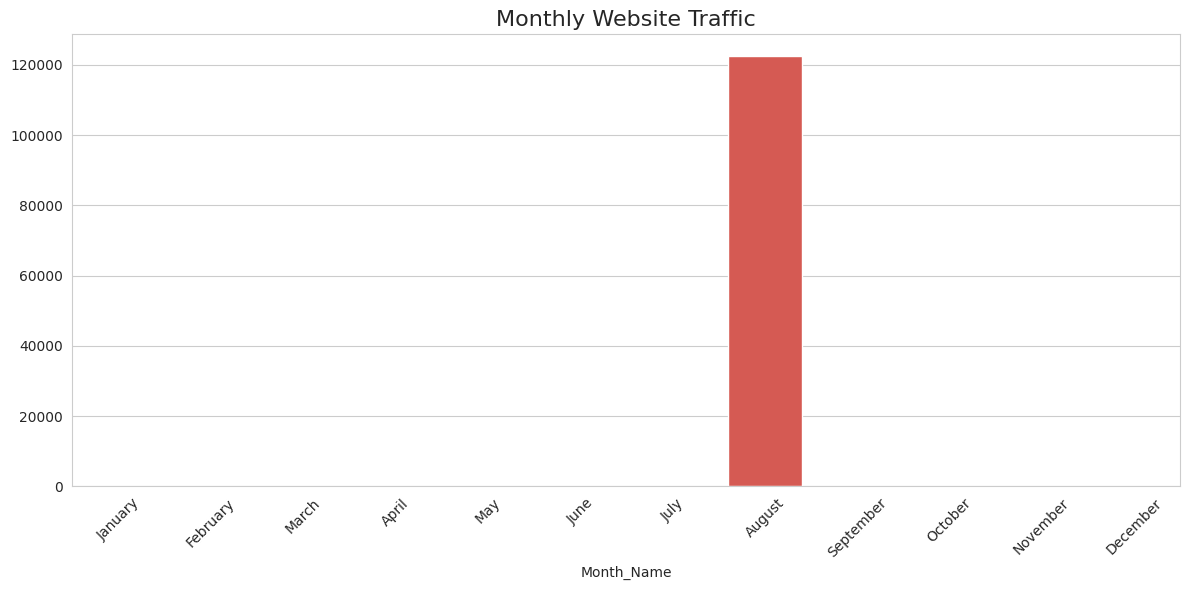

In [ ]:
# Chart 3: Monthly Website Traffic

monthly = (
    df.groupby("Month_Name")
      .size()
      .reindex([
          "January","February","March","April","May","June",
          "July","August","September","October","November","December"
      ])
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly.index,
    y=monthly.values,
    palette="rocket"
)

plt.xticks(rotation=45)

plt.title("Monthly Website Traffic", fontsize=16)

plt.tight_layout()

plt.savefig("Monthly Website Traffic.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/950219045.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


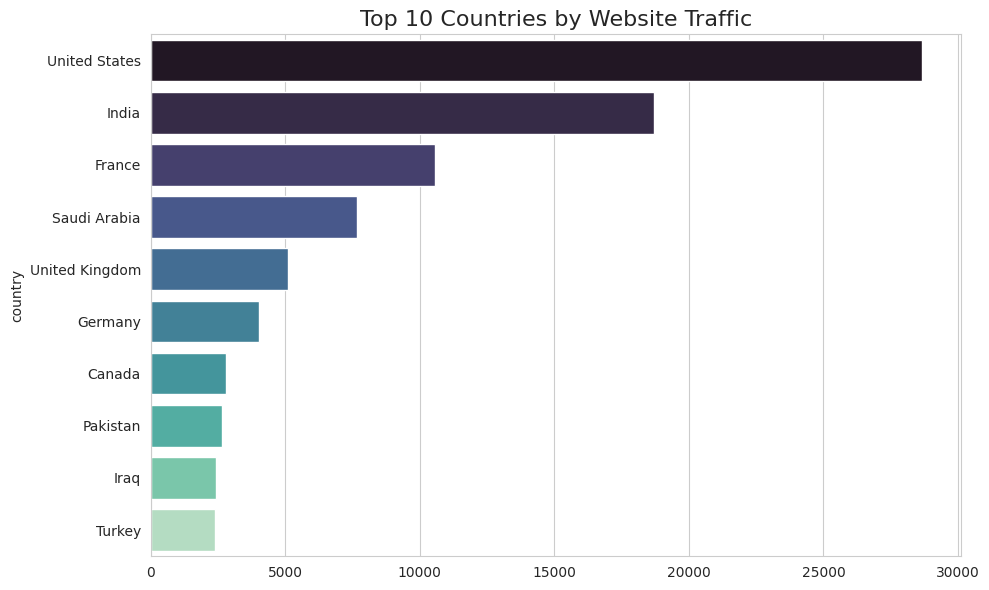

In [ ]:
# Chart 4: Top Countries

country = df["country"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=country.values,
    y=country.index,
    palette="mako"
)

plt.title("Top 10 Countries by Website Traffic", fontsize=16)

plt.tight_layout()

plt.savefig("Top 10 Countries.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/28163618.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


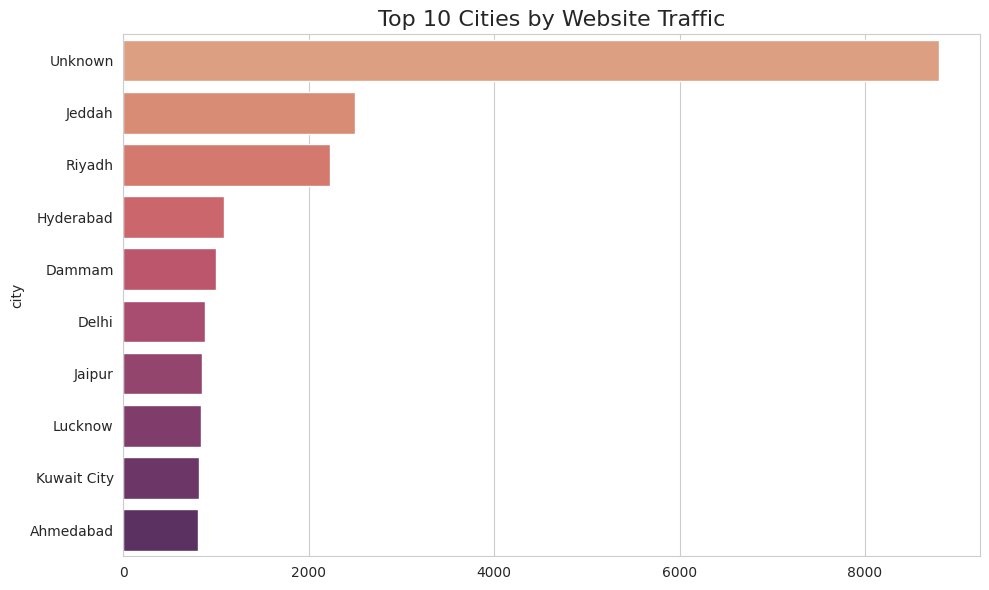

In [ ]:
# Chart 5: Top Cities

city = df["city"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=city.values,
    y=city.index,
    palette="flare"
)

plt.title("Top 10 Cities by Website Traffic", fontsize=16)

plt.tight_layout()

plt.savefig("Top 10 Cities.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/960035762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


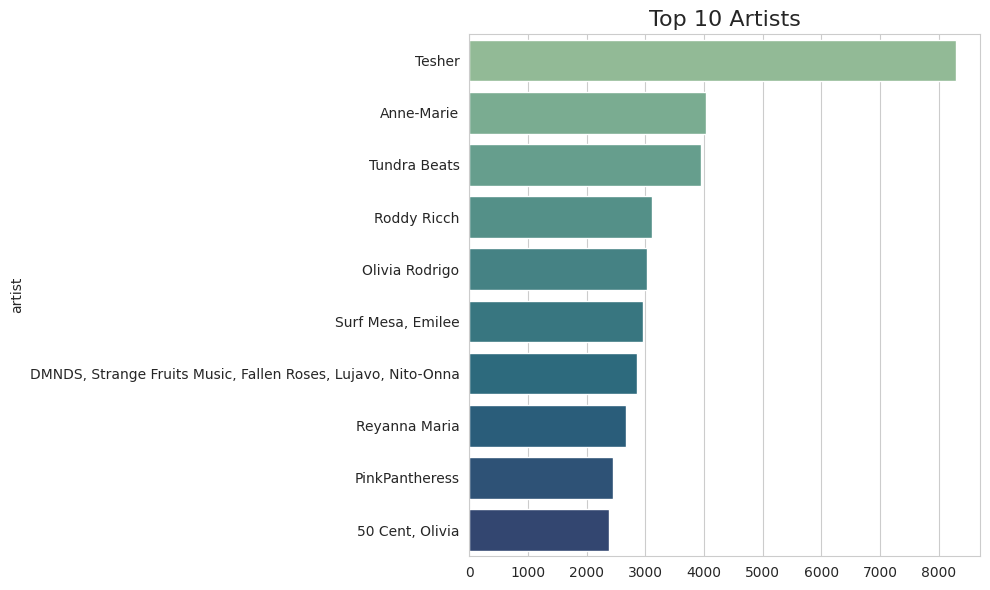

In [ ]:
# Chart 6: Top Artists

artist = df["artist"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=artist.values,
    y=artist.index,
    palette="crest"
)

plt.title("Top 10 Artists", fontsize=16)

plt.tight_layout()

plt.savefig("Top 10 Artists.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/3360058142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


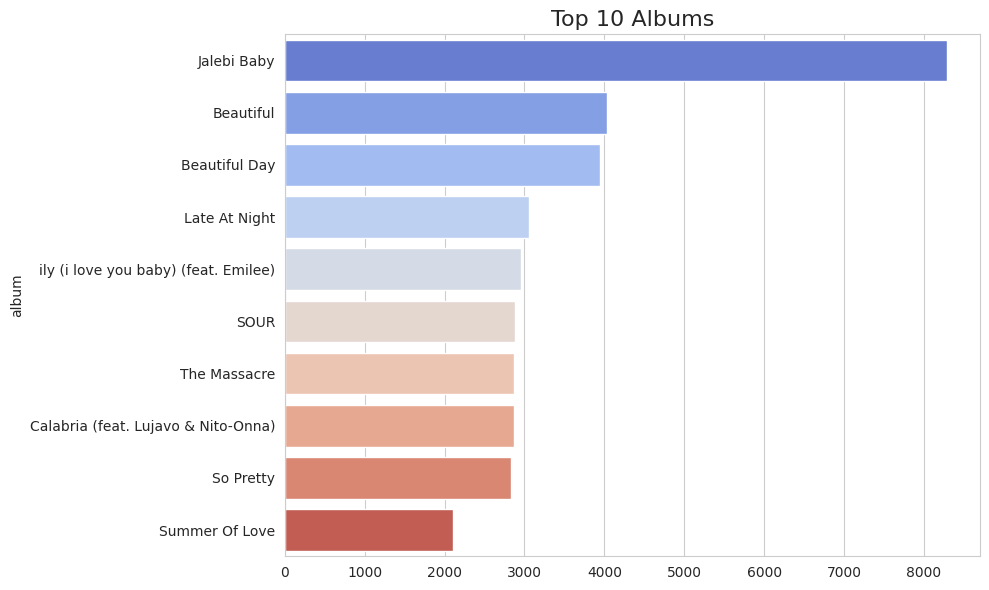

In [ ]:
# Chart 7: Top Albums

album = df["album"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=album.values,
    y=album.index,
    palette="coolwarm"
)

plt.title("Top 10 Albums", fontsize=16)

plt.tight_layout()

plt.savefig("Top 10 Albums.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/2885337240.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


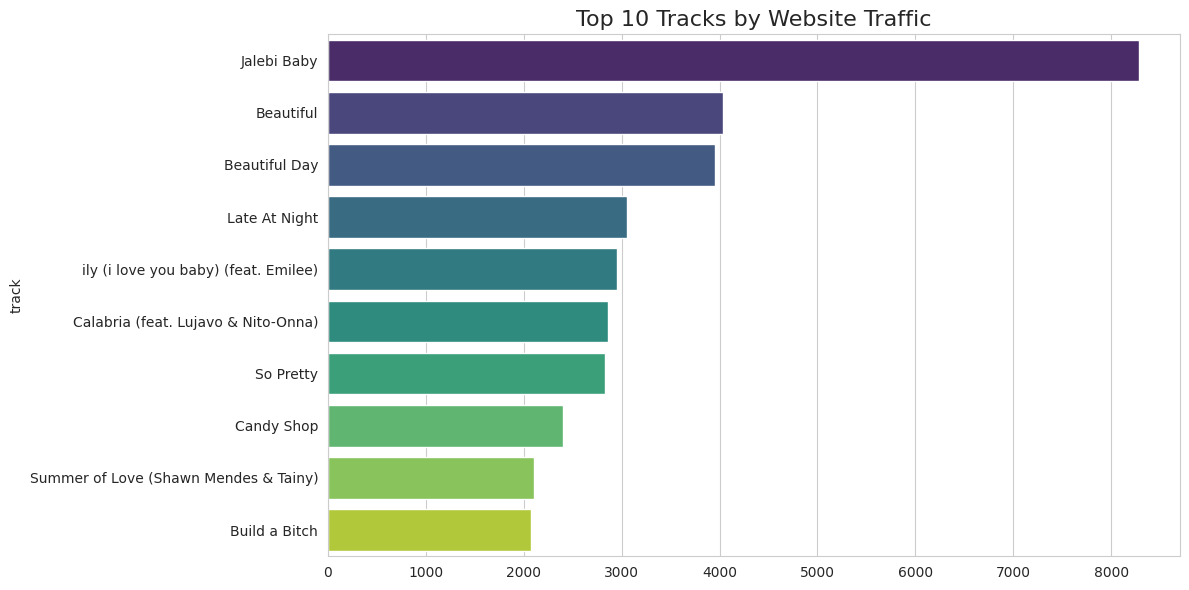

In [ ]:
# Chart 8: Top 10 Tracks

track = df["track"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=track.values,
    y=track.index,
    palette="viridis"
)

plt.title("Top 10 Tracks by Website Traffic", fontsize=16)

plt.tight_layout()

plt.savefig("Top 10 Tracks.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/86458903.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


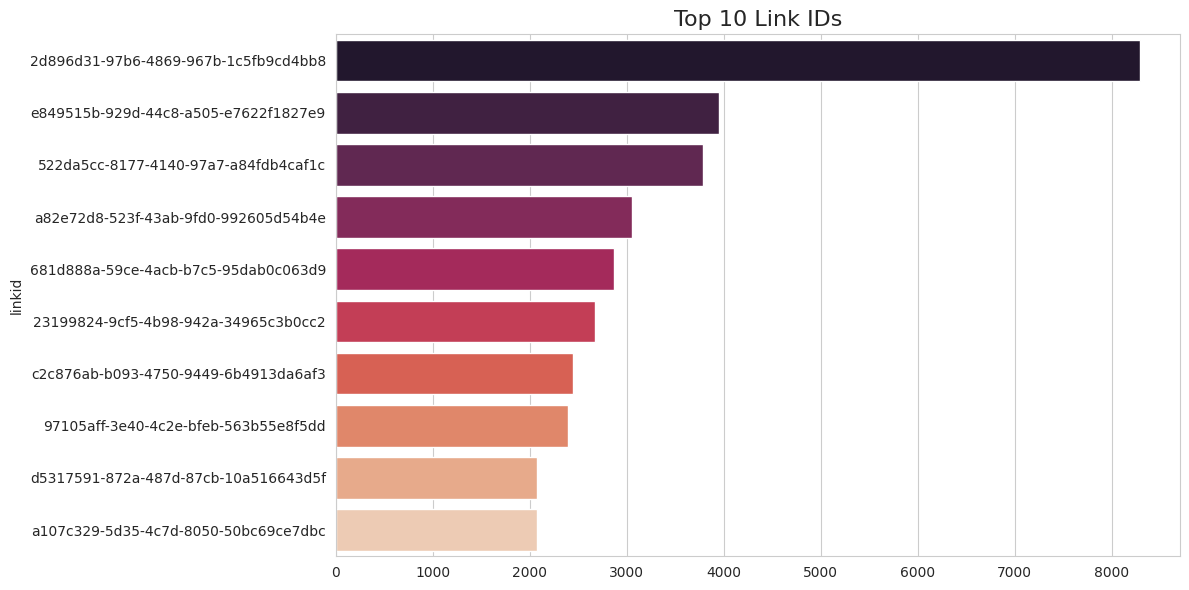

In [ ]:
# Chart 9: Top 10 Link IDs

link = df["linkid"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=link.values,
    y=link.index,
    palette="rocket"
)

plt.title("Top 10 Link IDs", fontsize=16)

plt.tight_layout()

plt.savefig("Top 10 Link IDs.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/2338395686.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


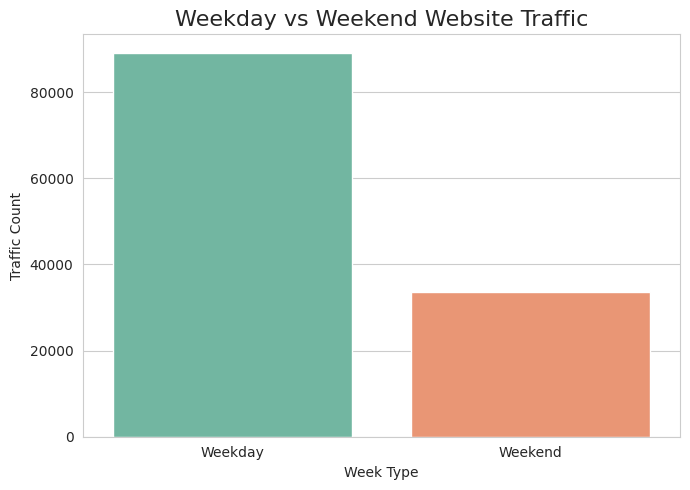

In [ ]:
# Chart 10: Weekday vs Weekend Traffic

week = df["Week_Type"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=week.index,
    y=week.values,
    palette="Set2"
)

plt.title("Weekday vs Weekend Website Traffic", fontsize=16)

plt.xlabel("Week Type")
plt.ylabel("Traffic Count")

plt.tight_layout()

plt.savefig("Weekday vs Weekend Traffic.png", dpi=300)

plt.show()

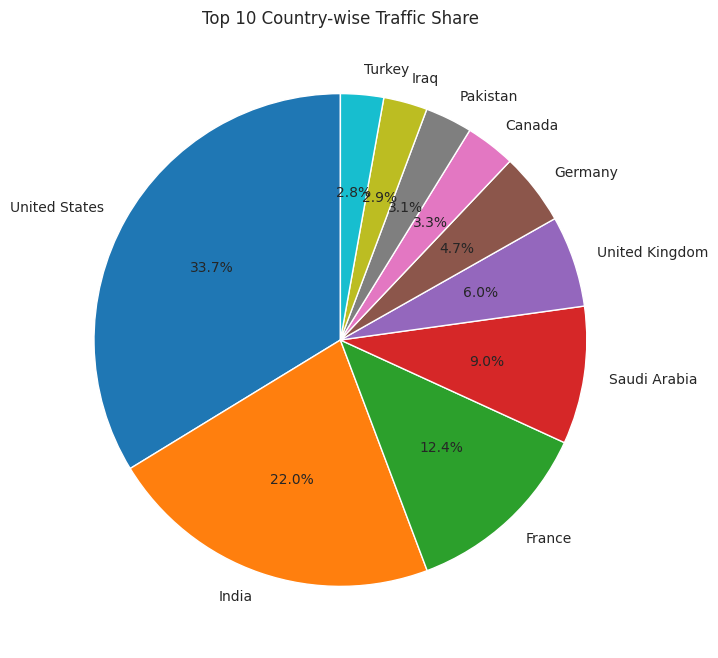

In [ ]:
# Chart 11: Country-wise Traffic Share

country = df["country"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    country.values,
    labels=country.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Country-wise Traffic Share")

plt.savefig("Country-wise Traffic Share.png", dpi=300)

plt.show()

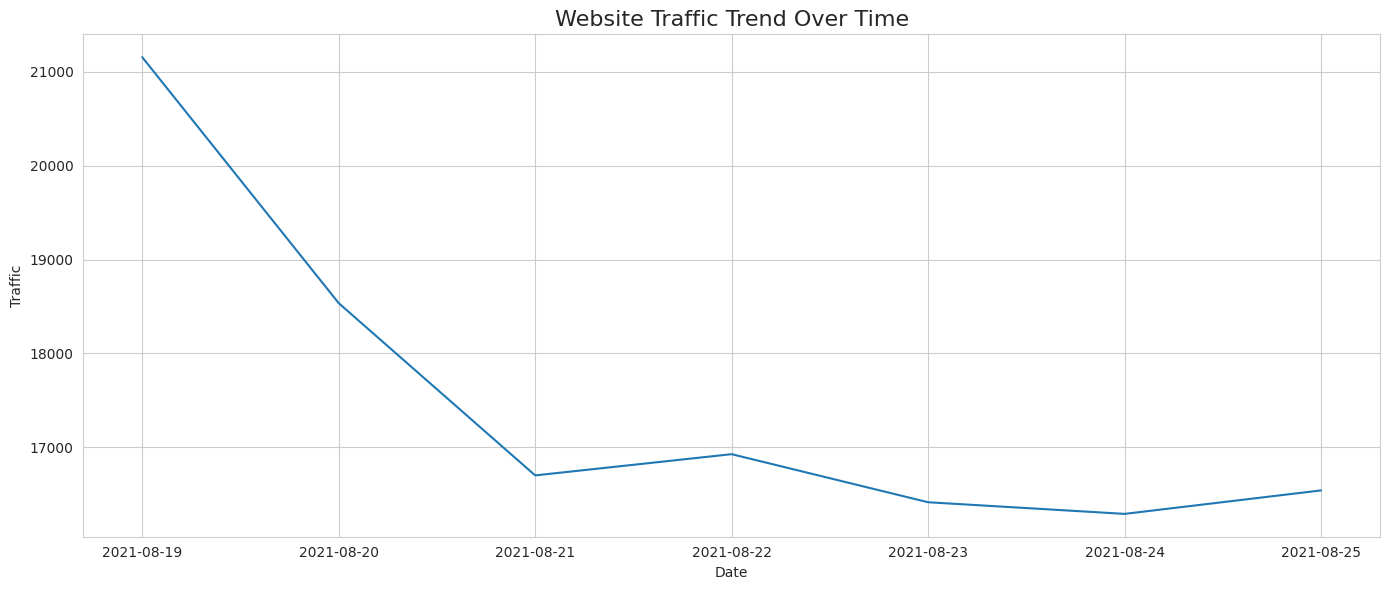

In [82]:
# Chart 12: Event Trend Over Time

trend = df.groupby("date").size()

plt.figure(figsize=(14,6))

plt.plot(
    trend.index,
    trend.values
)

plt.title("Website Traffic Trend Over Time", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Traffic")

plt.tight_layout()

plt.savefig("Website Traffic Trend.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/187562849.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


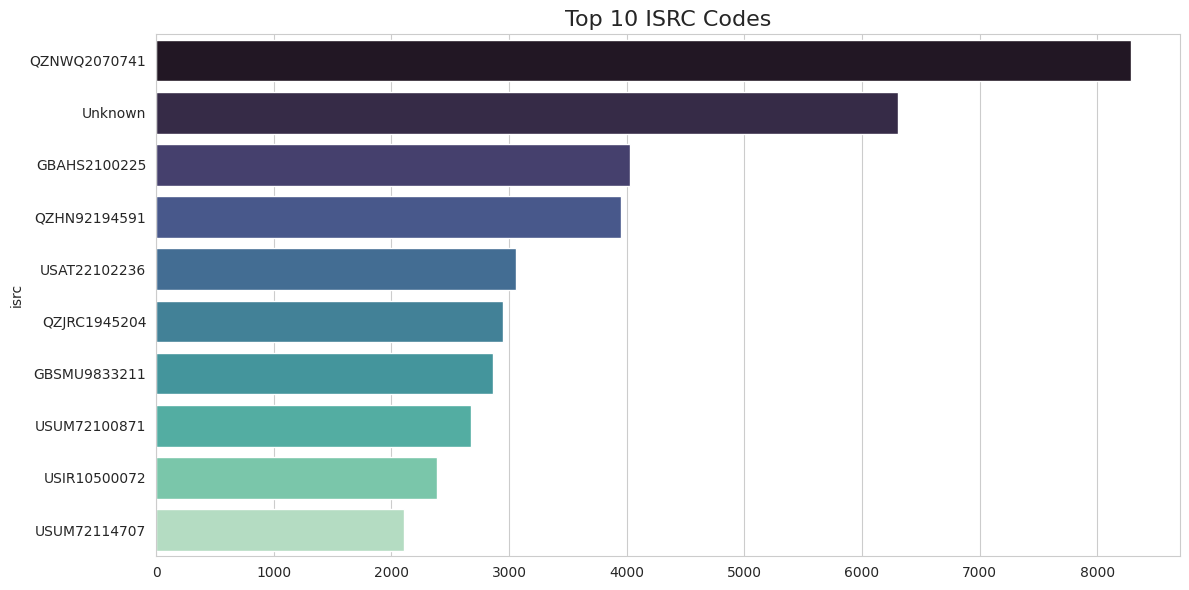

In [83]:
# Chart 13: Top ISRC Codes

isrc = df["isrc"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=isrc.values,
    y=isrc.index,
    palette="mako"
)

plt.title("Top 10 ISRC Codes", fontsize=16)

plt.tight_layout()

plt.savefig("Top 10 ISRC Codes.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/3127875415.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


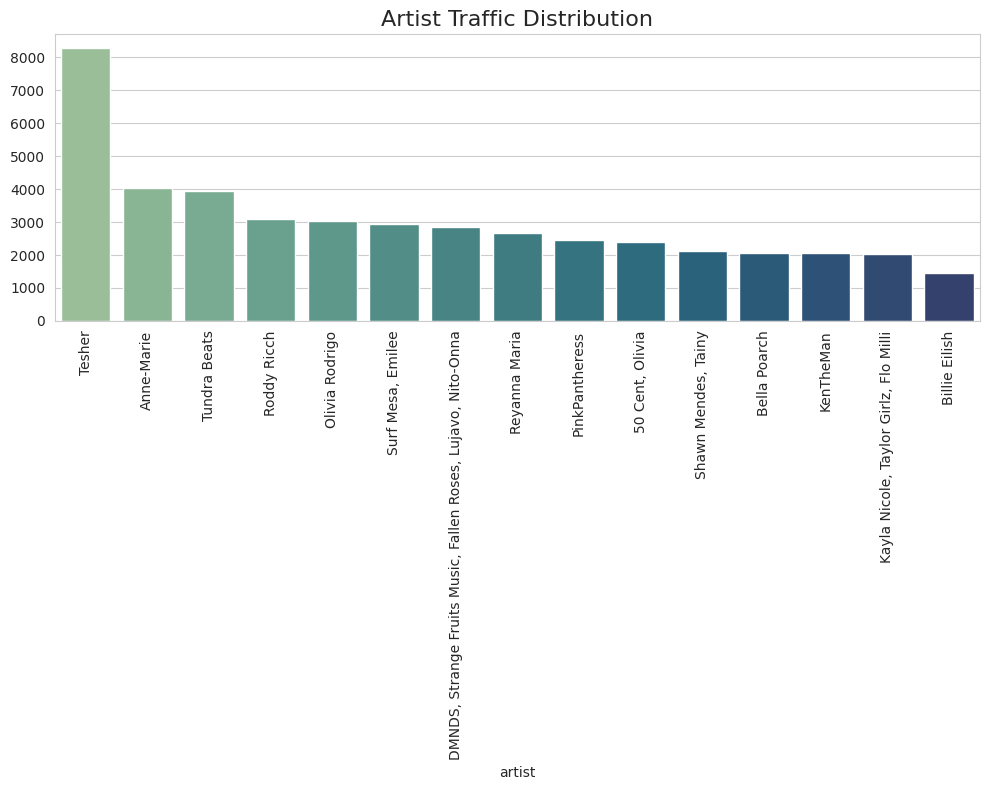

In [87]:
# Chart 14: Artist Traffic Distribution

artist = df["artist"].value_counts().head(15)

plt.figure(figsize=(10,8))

sns.barplot(
    x=artist.index,
    y=artist.values,
    palette="crest"
)

plt.xticks(rotation=90)

plt.title("Artist Traffic Distribution", fontsize=16)

plt.tight_layout()

plt.savefig("Artist Traffic Distribution.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/3338390648.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


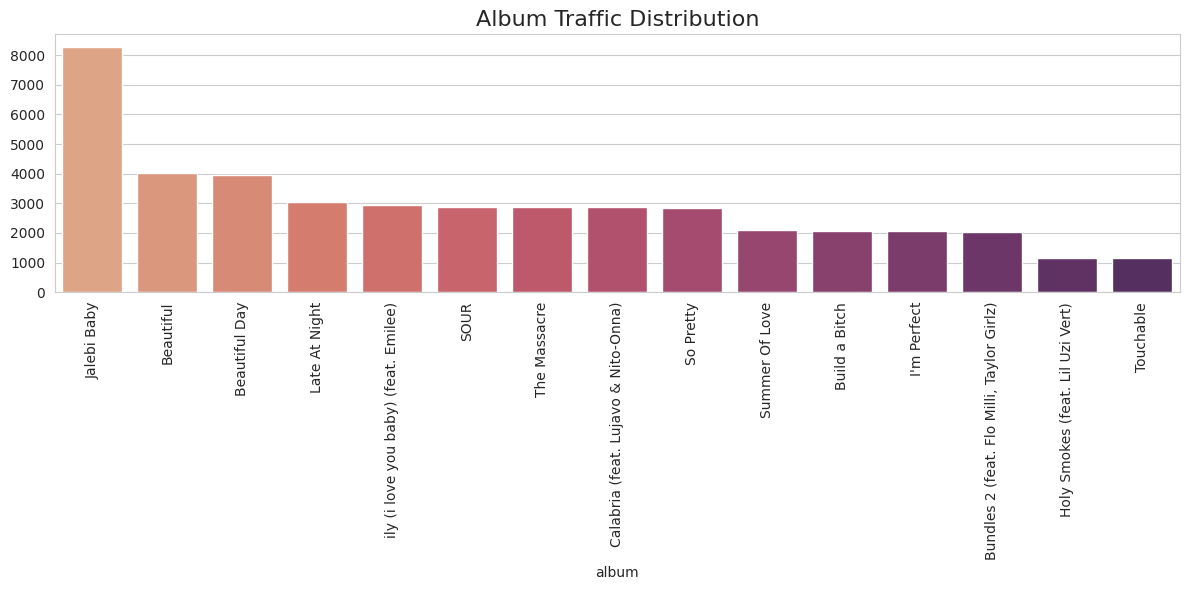

In [88]:
# Chart 15: Album Traffic Distribution

album = df["album"].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=album.index,
    y=album.values,
    palette="flare"
)

plt.xticks(rotation=90)

plt.title("Album Traffic Distribution", fontsize=16)

plt.tight_layout()

plt.savefig("Album Traffic Distribution.png", dpi=300)

plt.show()

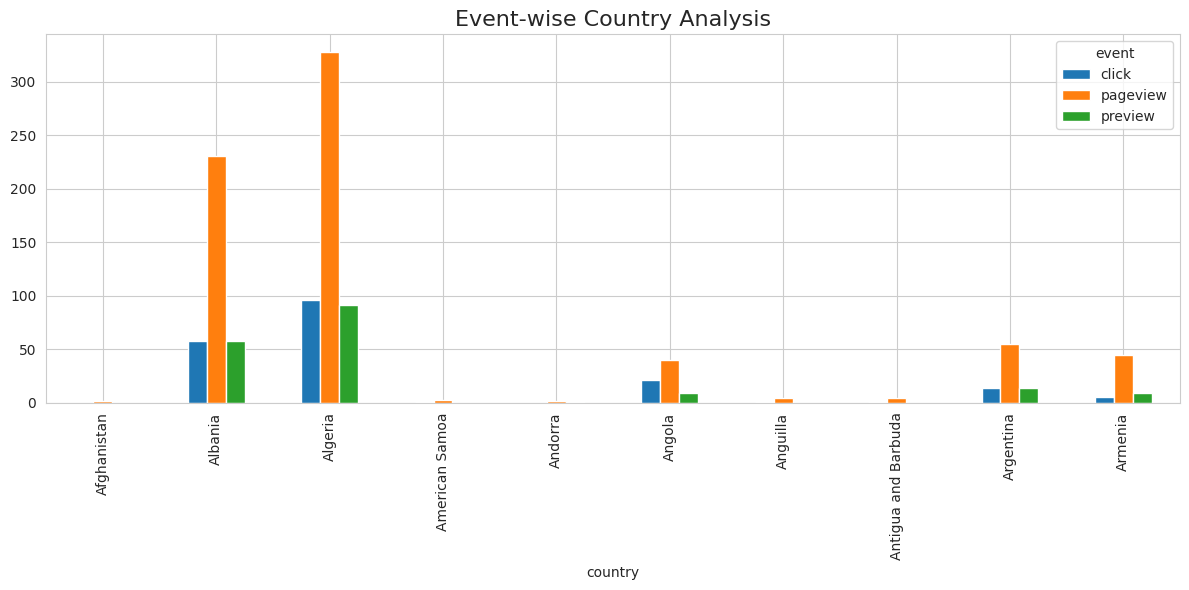

In [89]:
# Chart 16: Event-wise Country Analysis

country_event = pd.crosstab(df["country"], df["event"]).head(10)

country_event.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Event-wise Country Analysis", fontsize=16)

plt.tight_layout()

plt.savefig("Event-wise Country Analysis.png", dpi=300)

plt.show()

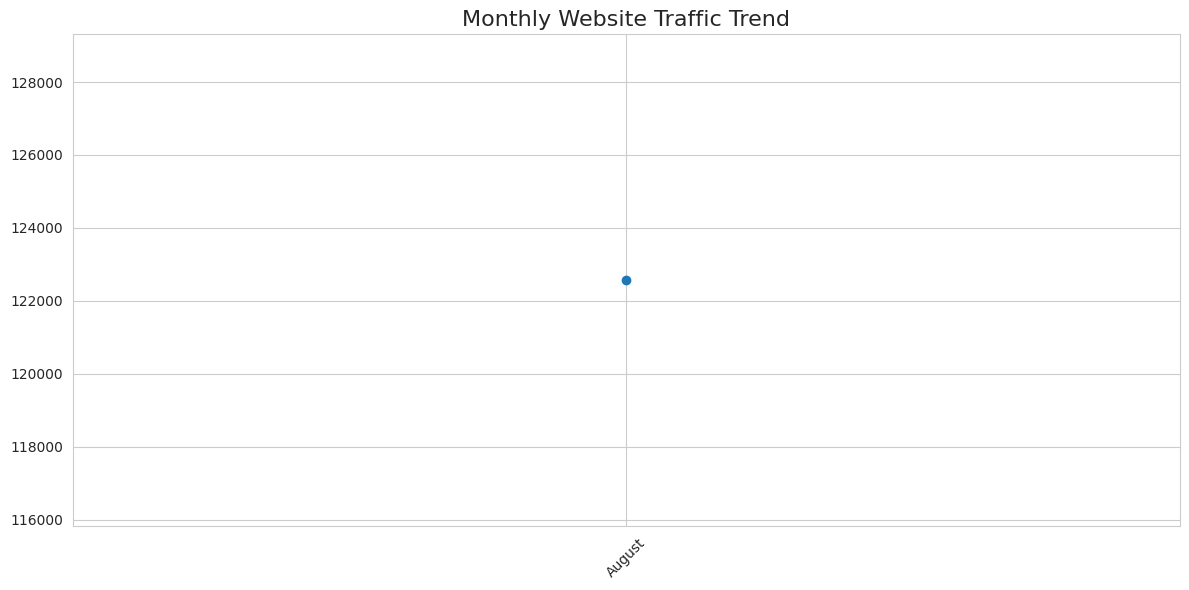

In [90]:
# Chart 17: Monthly Traffic Trend

month = df.groupby("Month_Name").size()

month = month.reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

plt.figure(figsize=(12,6))

plt.plot(
    month.index,
    month.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Website Traffic Trend", fontsize=16)

plt.tight_layout()

plt.savefig("Monthly Website Traffic Trend.png", dpi=300)

plt.show()

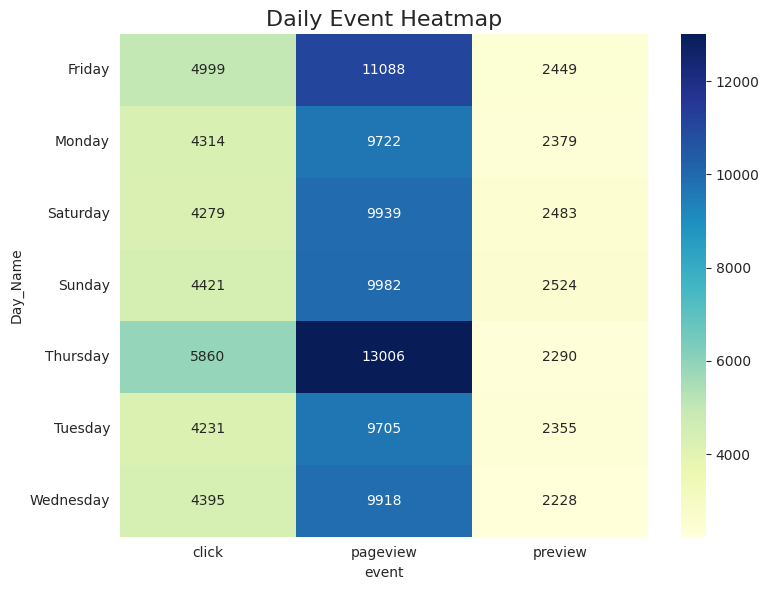

In [91]:
# Chart 18: Daily Event Heatmap

heat = pd.crosstab(
    df["Day_Name"],
    df["event"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heat,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Daily Event Heatmap", fontsize=16)

plt.tight_layout()

plt.savefig("Daily Event Heatmap.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/263676164.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


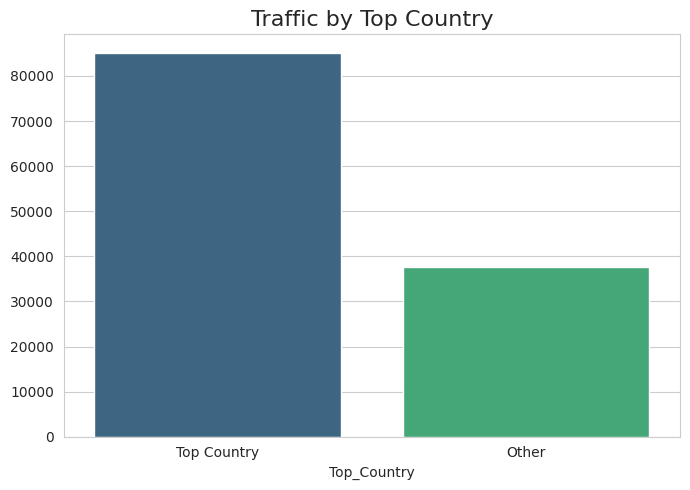

In [92]:
# Chart 19: Traffic by Top Country

country = df["Top_Country"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=country.index,
    y=country.values,
    palette="viridis"
)

plt.title("Traffic by Top Country", fontsize=16)

plt.tight_layout()

plt.savefig("Traffic by Top Country.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/2485567942.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


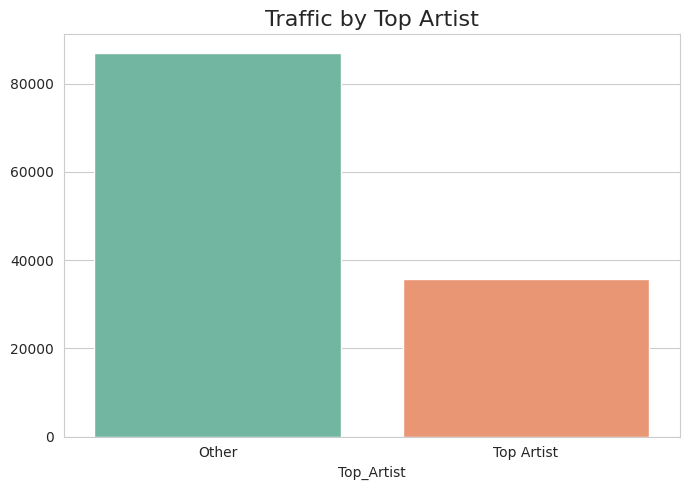

In [93]:
# Chart 20: Traffic by Top Artist

artist = df["Top_Artist"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=artist.index,
    y=artist.values,
    palette="Set2"
)

plt.title("Traffic by Top Artist", fontsize=16)

plt.tight_layout()

plt.savefig("Traffic by Top Artist.png", dpi=300)

plt.show()

/tmp/ipykernel_13463/3176941593.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


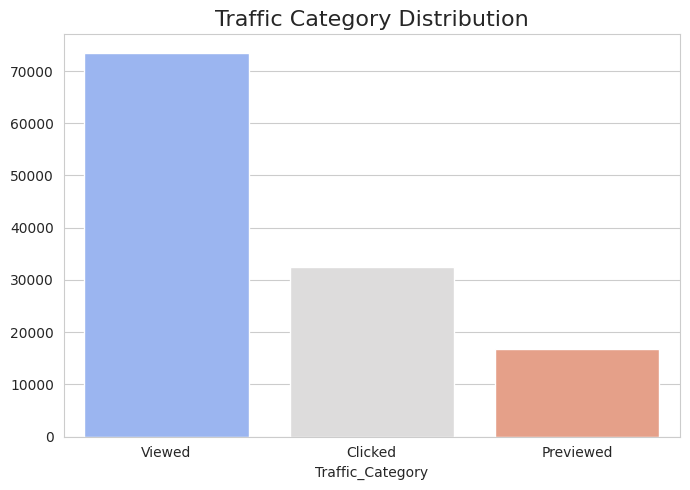

In [94]:
# Chart 21: Event Category Distribution

event_cat = df["Traffic_Category"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=event_cat.index,
    y=event_cat.values,
    palette="coolwarm"
)

plt.title("Traffic Category Distribution", fontsize=16)

plt.tight_layout()

plt.savefig("Traffic Category Distribution.png", dpi=300)

plt.show()

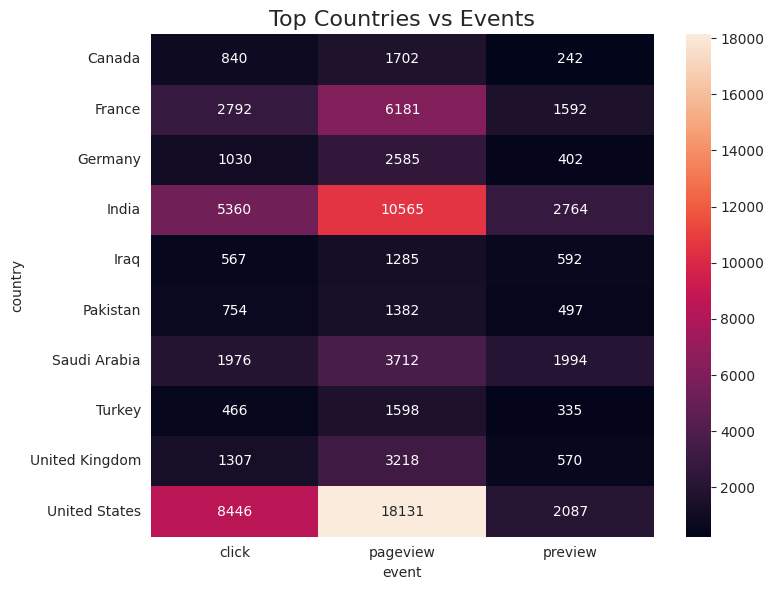

In [95]:
# Chart 22: Top 10 Countries and Events Heatmap

top10 = df["country"].value_counts().head(10).index

heat2 = pd.crosstab(
    df[df["country"].isin(top10)]["country"],
    df[df["country"].isin(top10)]["event"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heat2,
    annot=True,
    cmap="rocket",
    fmt="d"
)

plt.title("Top Countries vs Events", fontsize=16)

plt.tight_layout()

plt.savefig("Top Countries vs Events Heatmap.png", dpi=300)

plt.show()

In [96]:
# Total Website Events

total_events = len(df)

print("Total Website Events:", total_events)

Total Website Events: 122567


In [97]:
# Total Countries

total_countries = df["country"].nunique()

print("Total Countries:", total_countries)

Total Countries: 212


In [98]:
# Total Cities

total_cities = df["city"].nunique()

print("Total Cities:", total_cities)

Total Cities: 11993


In [99]:
# Total Artists

total_artists = df["artist"].nunique()

print("Total Artists:", total_artists)

Total Artists: 2420


In [100]:
# Total Albums

total_albums = df["album"].nunique()

print("Total Albums:", total_albums)

Total Albums: 3255


In [101]:
# Total Tracks

total_tracks = df["track"].nunique()

print("Total Tracks:", total_tracks)

Total Tracks: 3563


In [102]:
# Most Popular Event

popular_event = df["event"].mode()[0]

popular_event_count = df["event"].value_counts().iloc[0]

print("Most Popular Event:", popular_event)
print("Event Count:", popular_event_count)

Most Popular Event: pageview
Event Count: 73360


In [103]:
# Most Active Country

top_country = df["country"].mode()[0]

top_country_count = df["country"].value_counts().iloc[0]

print("Most Active Country:", top_country)
print("Traffic:", top_country_count)

Most Active Country: United States
Traffic: 28664


In [104]:
# Most Active City

top_city = df["city"].mode()[0]

top_city_count = df["city"].value_counts().iloc[0]

print("Most Active City:", top_city)
print("Traffic:", top_city_count)

Most Active City: Unknown
Traffic: 8802


In [105]:
# Top Artist

top_artist = df["artist"].mode()[0]

top_artist_count = df["artist"].value_counts().iloc[0]

print("Top Artist:", top_artist)
print("Traffic:", top_artist_count)

Top Artist: Tesher
Traffic: 8288


In [106]:
# Top Album

top_album = df["album"].mode()[0]

top_album_count = df["album"].value_counts().iloc[0]

print("Top Album:", top_album)
print("Traffic:", top_album_count)

Top Album: Jalebi Baby
Traffic: 8288


In [107]:
# KPI Summary

kpi_summary = pd.DataFrame({

    "KPI":[

        "Total Website Events",
        "Total Countries",
        "Total Cities",
        "Total Artists",
        "Total Albums",
        "Total Tracks",
        "Most Popular Event",
        "Most Active Country",
        "Most Active City",
        "Top Artist",
        "Top Album"

    ],

    "Value":[

        total_events,
        total_countries,
        total_cities,
        total_artists,
        total_albums,
        total_tracks,
        popular_event,
        top_country,
        top_city,
        top_artist,
        top_album

    ]

})

kpi_summary

,KPI,Value
0,Total Website Events,122567
1,Total Countries,212
2,Total Cities,11993
3,Total Artists,2420
4,Total Albums,3255
5,Total Tracks,3563
6,Most Popular Event,pageview
7,Most Active Country,United States
8,Most Active City,Unknown
9,Top Artist,Tesher


In [108]:
# Save KPI Summary

kpi_summary.to_csv(
    "Website Traffic KPI Summary.csv",
    index=False
)

print("KPI Summary Saved Successfully!")

KPI Summary Saved Successfully!


/tmp/ipykernel_13463/3311753010.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


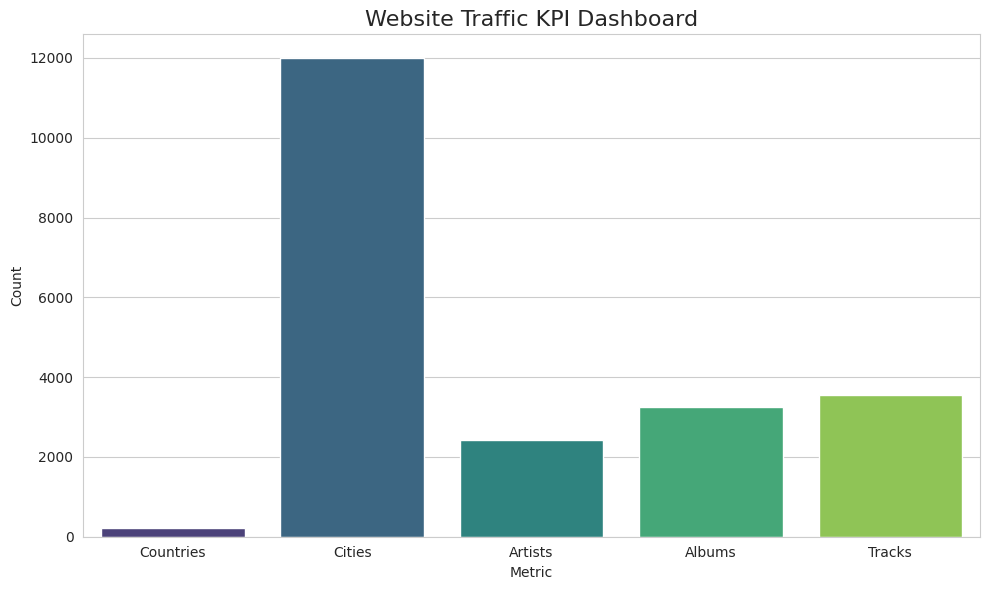

In [109]:
# KPI Dashboard

dashboard = pd.DataFrame({

    "Metric":[
        "Countries",
        "Cities",
        "Artists",
        "Albums",
        "Tracks"
    ],

    "Count":[
        total_countries,
        total_cities,
        total_artists,
        total_albums,
        total_tracks
    ]

})

plt.figure(figsize=(10,6))

sns.barplot(
    data=dashboard,
    x="Metric",
    y="Count",
    palette="viridis"
)

plt.title("Website Traffic KPI Dashboard", fontsize=16)

plt.tight_layout()

plt.savefig(
    "Website Traffic KPI Dashboard.png",
    dpi=300
)

plt.show()